# Eksperimen 1: Tes MediaPipe BlazePose pada 1 Video
Notebook ini digunakan untuk menguji pipeline ekstraksi pose menggunakan MediaPipe BlazePose pada satu file video sampel.

**Output yang dihasilkan:**
* `../data/processed/sample_video_pose.npy` — Array NumPy pose skeleton dengan bentuk (T, 33, 4)
* `../data/processed/sample_video_skeleton.mp4` — Video visualisasi skeleton hasil deteksi pose

### 1. Import Library & Konfigurasi Path

In [1]:
# ============================================================
# Import library standar dan tambahkan src/ ke sys.path
# agar modul lokal (PoseExtractor) dapat diimpor dari notebook
# ============================================================
import sys
import os

import numpy as np
import matplotlib.pyplot as plt

# Tambahkan direktori src/ ke Python path agar bisa mengimpor modul lokal
sys.path.insert(0, os.path.abspath("../src"))

from data.extract_pose import PoseExtractor

print("Import berhasil.")
print(f"Python path aktif: {sys.path[0]}")

Import berhasil.
Python path aktif: d:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\src


### 2. Definisi Path Input & Output

In [2]:
# ============================================================
# Definisi path file — sesuaikan jika nama video berbeda
# ============================================================
# Path video mentah yang akan diproses
VIDEO_INPUT_PATH = "../data/raw/sample_video.mp4"

# Path output: file array NumPy pose skeleton
NPY_OUTPUT_PATH = "../data/processed/sample_video_pose.npy"

# Path output: video visualisasi skeleton (set None untuk menonaktifkan)
VIDEO_OUTPUT_PATH = "../data/processed/sample_video_skeleton.mp4"

print(f"Input  : {os.path.abspath(VIDEO_INPUT_PATH)}")
print(f"Output : {os.path.abspath(NPY_OUTPUT_PATH)}")
print(f"Output : {os.path.abspath(VIDEO_OUTPUT_PATH)}")

# Cek apakah file input tersedia
if not os.path.exists(VIDEO_INPUT_PATH):
    print("\n[PERINGATAN] File video input belum ada di path tersebut.")
    print(" Letakkan file video di '../data/raw/sample_video.mp4' dan jalankan ulang cell ini.")
else:
    print("\n[OK] File video input ditemukan.")

Input  : d:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\data\raw\sample_video.mp4
Output : d:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\data\processed\sample_video_pose.npy
Output : d:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\data\processed\sample_video_skeleton.mp4

[OK] File video input ditemukan.


### 3. Inisialisasi PoseExtractor

In [3]:
# ============================================================
# Inisialisasi PoseExtractor dengan model_complexity=2 (Heavy)
# untuk mendapatkan akurasi landmark tertinggi.
# ============================================================
extractor = PoseExtractor(
    model_complexity=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)

print("PoseExtractor berhasil diinisialisasi.")
print(f" model_complexity         : {extractor.model_complexity}")
print(f" min_detection_confidence : {extractor.min_detection_confidence}")
print(f" min_tracking_confidence  : {extractor.min_tracking_confidence}")

PoseExtractor berhasil diinisialisasi.
 model_complexity         : 2
 min_detection_confidence : 0.5
 min_tracking_confidence  : 0.5


### 4. Jalankan Ekstraksi Pose

In [4]:
# ============================================================
# Jalankan ekstraksi pose dari video sampel.
# Proses ini mungkin membutuhkan beberapa menit tergantung
# panjang video dan spesifikasi hardware.
# ============================================================
pose_array = extractor.extract_video(
    video_path=VIDEO_INPUT_PATH,
    output_npy_path=NPY_OUTPUT_PATH,
    output_video_path=VIDEO_OUTPUT_PATH,
)

print(f"\nEkstraksi selesai.")
print(f"Bentuk array hasil : {pose_array.shape} → (Jumlah Frame, 33 Landmark, 4 Koordinat [x,y,z,vis])")

[INFO] Membuka video: ../data/raw/sample_video.mp4
[INFO] Resolusi: 1920x1080 | FPS: 29.97 | Total Frame: 150
[INFO] Output video skeleton akan disimpan ke: ../data/processed/sample_video_skeleton.mp4


c:\Users\Administrator\anaconda3\envs\attentiveskel\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


[INFO] Pemrosesan selesai.
[INFO] Frame dengan pose terdeteksi : 150
[INFO] Frame tanpa pose             : 0
[INFO] Bentuk array pose akhir: (150, 33, 4)  (Frame x 33 Landmark x 4 Koordinat)
[INFO] Array pose disimpan ke: ../data/processed/sample_video_pose.npy

Ekstraksi selesai.
Bentuk array hasil : (150, 33, 4) → (Jumlah Frame, 33 Landmark, 4 Koordinat [x,y,z,vis])


### 5. Verifikasi & Inspeksi Data Hasil Ekstraksi

In [5]:
# ============================================================
# Muat ulang file .npy dari disk untuk memverifikasi bahwa
# data tersimpan dengan benar.
# ============================================================
loaded_array = np.load(NPY_OUTPUT_PATH)

print(f"File .npy berhasil dimuat dari: {NPY_OUTPUT_PATH}")
print(f"Tipe data : {loaded_array.dtype}")
print(f"Bentuk    : {loaded_array.shape} → ({loaded_array.shape[0]} frame, 33 landmark, 4 nilai)")
print(f"\nKoordinat landmark pertama pada frame ke-0:")
print(f"{'Landmark':>10} {'x':>10} {'y':>10} {'z':>10} {'vis':>10}")
print("-" * 55)
for i, lm in enumerate(loaded_array[0]):
    print(f"{i:>10} {lm[0]:>10.4f} {lm[1]:>10.4f} {lm[2]:>10.4f} {lm[3]:>10.4f}")

File .npy berhasil dimuat dari: ../data/processed/sample_video_pose.npy
Tipe data : float32
Bentuk    : (150, 33, 4) → (150 frame, 33 landmark, 4 nilai)

Koordinat landmark pertama pada frame ke-0:
  Landmark          x          y          z        vis
-------------------------------------------------------
         0     0.8298     0.4274    -0.1151     0.9817
         1     0.8303     0.4058    -0.1041     0.9792
         2     0.8290     0.4035    -0.1043     0.9774
         3     0.8274     0.4011    -0.1044     0.9868
         4     0.8304     0.4062    -0.1321     0.9854
         5     0.8293     0.4046    -0.1322     0.9838
         6     0.8279     0.4026    -0.1323     0.9889
         7     0.8123     0.3916    -0.0615     0.9938
         8     0.8136     0.3934    -0.1903     0.9854
         9     0.8197     0.4354    -0.0962     0.9834
        10     0.8195     0.4360    -0.1348     0.9861
        11     0.7574     0.4481    -0.0026     0.9999
        12     0.7666     0.482

### 6. Visualisasi: Grafik Pergerakan Keypoint Sepanjang Waktu

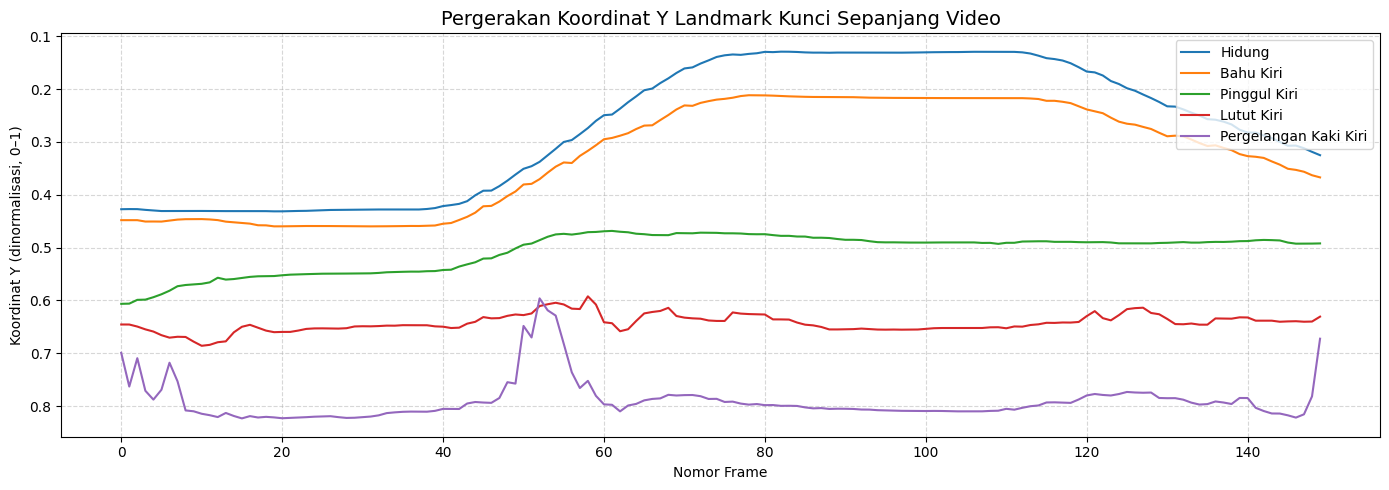

In [6]:
# ============================================================
# Plot koordinat Y (vertikal) dari beberapa landmark kunci
# sepanjang seluruh durasi video sebagai sanity check visual.
# Landmark yang dipilih:
# 0 = Hidung (Nose)
# 11 = Bahu Kiri (Left Shoulder)
# 23 = Pinggul Kiri (Left Hip)
# 25 = Lutut Kiri (Left Knee)
# 27 = Pergelangan Kaki Kiri (Left Ankle)
# ============================================================
LANDMARK_LABELS = {
    0: "Hidung",
    11: "Bahu Kiri",
    23: "Pinggul Kiri",
    25: "Lutut Kiri",
    27: "Pergelangan Kaki Kiri",
}

fig, ax = plt.subplots(figsize=(14, 5))

for lm_idx, label in LANDMARK_LABELS.items():
    # Ambil koordinat Y dari semua frame untuk landmark ini
    y_coords = loaded_array[:, lm_idx, 1]
    ax.plot(y_coords, label=label)

# Sumbu Y MediaPipe bertambah ke bawah, balik agar atas = lebih tinggi
ax.invert_yaxis()
ax.set_title("Pergerakan Koordinat Y Landmark Kunci Sepanjang Video", fontsize=14)
ax.set_xlabel("Nomor Frame")
ax.set_ylabel("Koordinat Y (dinormalisasi, 0–1)")
ax.legend(loc="upper right")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()